# 🤖 02 — Training Model KNN

Notebook ini mencakup:
1. Preprocessing & normalisasi data
2. Split train/test
3. Hyperparameter tuning (cari nilai K terbaik)
4. Evaluasi model: akurasi, confusion matrix, classification report
5. Simpan model dan scaler ke folder `models/`

**Prasyarat:** Jalankan `01_eksplorasi_data.ipynb` → `data/processed/dataset_clean.csv` harus ada.

In [3]:
import sys, os
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.neighbors   import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

from config import (
    FEATURES, TARGET, CLASSES, CLASS_MAP,
    K_NEIGHBORS, KNN_METRIC, KNN_WEIGHTS,
    MODEL_PATH, SCALER_PATH
)
from utils import load_and_clean_dataset, normalize_features, encode_labels, get_logger

logger = get_logger('notebook_02')
sns.set_theme(style='whitegrid')
print('Library siap.')

Library siap.


## 1. Muat Dataset Bersih

In [4]:
CLEAN_PATH = '../data/processed/dataset_clean.csv'

df = load_and_clean_dataset(CLEAN_PATH)
df = encode_labels(df)

print(f'Shape: {df.shape}')
print(f'Distribusi kelas:\n{df[TARGET].value_counts()}')
df[FEATURES + [TARGET]].head()

Shape: (179, 7)
Distribusi kelas:
activity
DUDUK       60
BERJALAN    60
BERLARI     59
Name: count, dtype: int64


,accel_stddev,gyro_stddev,activity
0,0.006552,0.0291,DUDUK
1,0.005946,0.0236,DUDUK
2,0.005978,0.0152,DUDUK
3,0.005402,0.0189,DUDUK
4,0.005159,0.0193,DUDUK


## 2. Preprocessing — Normalisasi Fitur

In [5]:
X = df[FEATURES].values
y = df[TARGET].values

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print('Sebelum normalisasi:')
print(pd.DataFrame(X, columns=FEATURES).describe().round(5))
print('\nSetelah normalisasi (min=0, max=1):')
print(pd.DataFrame(X_scaled, columns=FEATURES).describe().round(5))

Sebelum normalisasi:
       accel_stddev  gyro_stddev
count     179.00000    179.00000
mean        0.07764     20.74920
std         0.06664     16.06511
min         0.00374      0.01520
25%         0.00888      1.11135
50%         0.07263     24.99430
75%         0.13454     33.04205
max         0.25302     58.73380

Setelah normalisasi (min=0, max=1):
       accel_stddev  gyro_stddev
count     179.00000    179.00000
mean        0.29645      0.35311
std         0.26731      0.27359
min         0.00000      0.00000
25%         0.02061      0.01867
50%         0.27635      0.42540
75%         0.52470      0.56246
max         1.00000      1.00000


## 3. Split Train / Test

In [6]:
TEST_SIZE   = 0.20   # 80% train, 20% test
RANDOM_SEED = 42

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y          # proporsional tiap kelas
)

print(f'Train: {X_train.shape[0]} sampel')
print(f'Test : {X_test.shape[0]} sampel')
print(f'\nDistribusi kelas train:')
for cls in CLASSES:
    cnt = np.sum(y_train == cls)
    print(f'  {cls}: {cnt}')

Train: 143 sampel
Test : 36 sampel

Distribusi kelas train:
  DUDUK: 48
  BERJALAN: 48
  BERLARI: 47


## 4. Hyperparameter Tuning — Cari K Terbaik

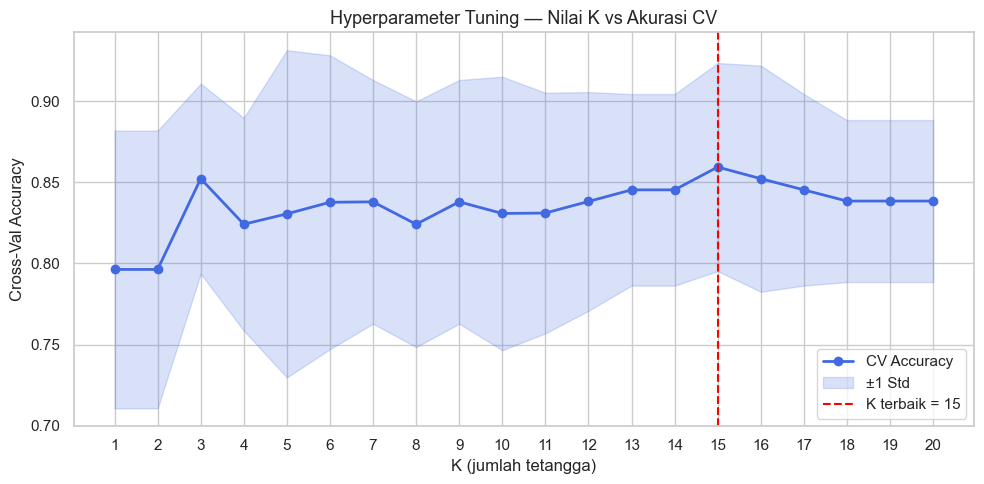


✅  K terbaik: 15 (CV Accuracy = 85.94%)


In [7]:
k_range    = range(1, 21)
cv_scores  = []
cv_std     = []
kfold      = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric=KNN_METRIC, weights=KNN_WEIGHTS)
    scores = cross_val_score(knn, X_train, y_train, cv=kfold, scoring='accuracy')
    cv_scores.append(scores.mean())
    cv_std.append(scores.std())

cv_scores = np.array(cv_scores)
cv_std    = np.array(cv_std)

best_k     = k_range[np.argmax(cv_scores)]
best_score = cv_scores.max()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(list(k_range), cv_scores, 'o-', color='royalblue', linewidth=2, label='CV Accuracy')
plt.fill_between(list(k_range),
                 cv_scores - cv_std,
                 cv_scores + cv_std,
                 alpha=0.2, color='royalblue', label='±1 Std')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'K terbaik = {best_k}')
plt.xlabel('K (jumlah tetangga)', fontsize=12)
plt.ylabel('Cross-Val Accuracy', fontsize=12)
plt.title('Hyperparameter Tuning — Nilai K vs Akurasi CV', fontsize=13)
plt.xticks(list(k_range))
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/tuning_k.png', dpi=150)
plt.show()

print(f'\n✅  K terbaik: {best_k} (CV Accuracy = {best_score*100:.2f}%)')

## 5. Training Model Final

In [8]:
# Gunakan K terbaik dari tuning, atau override dengan K dari config
USE_K = best_k   # ganti dengan K_NEIGHBORS dari config jika ingin fixed

knn = KNeighborsClassifier(
    n_neighbors = USE_K,
    metric      = KNN_METRIC,
    weights     = KNN_WEIGHTS
)
knn.fit(X_train, y_train)

# Prediksi test set
y_pred = knn.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f'Model dilatih dengan K={USE_K}')
print(f'Test Accuracy : {acc*100:.2f}%')

Model dilatih dengan K=15
Test Accuracy : 83.33%


## 6. Evaluasi — Classification Report

In [9]:
print('=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred, target_names=CLASSES, digits=4))

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

       DUDUK     0.7500    0.7500    0.7500        12
    BERJALAN     0.7692    0.8333    0.8000        12
     BERLARI     1.0000    0.9167    0.9565        12

    accuracy                         0.8333        36
   macro avg     0.8397    0.8333    0.8355        36
weighted avg     0.8397    0.8333    0.8355        36



## 7. Confusion Matrix

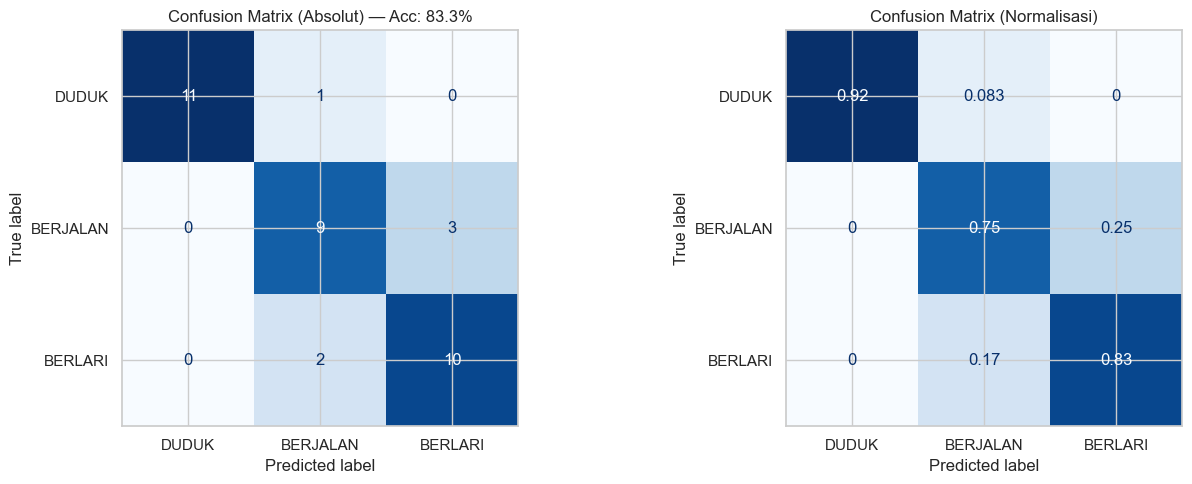

In [10]:
cm = confusion_matrix(y_test, y_pred, labels=CLASSES)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolut
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp1.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix (Absolut) — Acc: {acc*100:.1f}%', fontsize=12)

# Normalisasi
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm.round(3), display_labels=CLASSES)
disp2.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix (Normalisasi)', fontsize=12)

plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix.png', dpi=150)
plt.show()

## 8. Decision Boundary (Visualisasi Ruang Fitur)

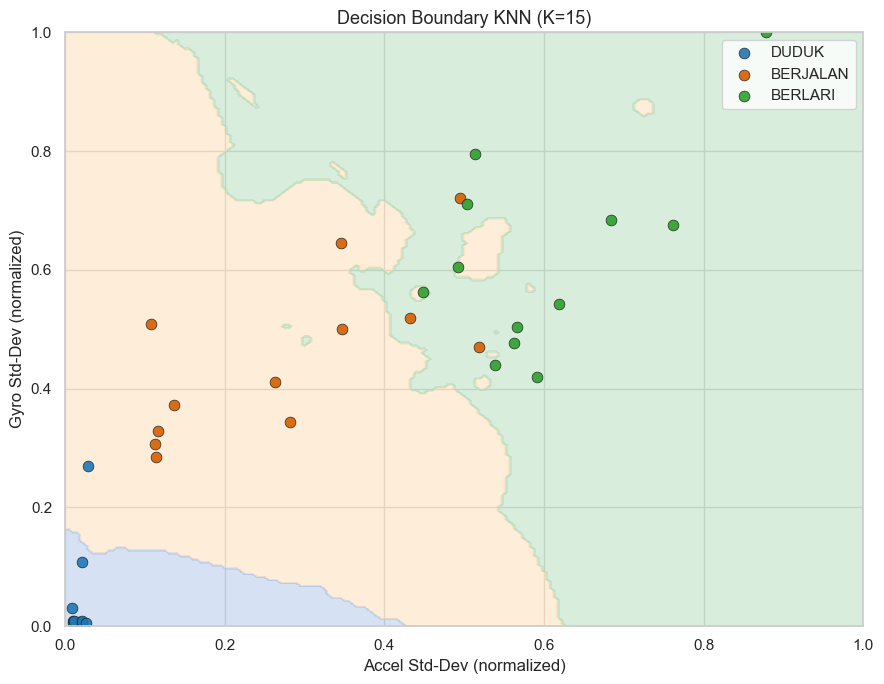

In [11]:
from matplotlib.colors import ListedColormap

colors_bg = ['#AEC6E8', '#FDDCB5', '#B5DDBC']
colors_pt = ['#1F77B4', '#D55E00', '#2CA02C']

h = 0.005
xx, yy = np.meshgrid(
    np.arange(0, 1 + h, h),
    np.arange(0, 1 + h, h)
)

label_to_num = {cls: i for i, cls in enumerate(CLASSES)}
num_to_label = {i: cls for cls, i in label_to_num.items()}

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z_num = np.array([label_to_num[z] for z in Z]).reshape(xx.shape)

plt.figure(figsize=(9, 7))
plt.contourf(xx, yy, Z_num, cmap=ListedColormap(colors_bg), alpha=0.5)

for i, cls in enumerate(CLASSES):
    idx = y_test == cls
    plt.scatter(X_test[idx, 0], X_test[idx, 1],
                c=colors_pt[i], label=cls, edgecolors='k',
                linewidth=0.5, s=60, alpha=0.9)

plt.xlabel('Accel Std-Dev (normalized)', fontsize=12)
plt.ylabel('Gyro Std-Dev (normalized)', fontsize=12)
plt.title(f'Decision Boundary KNN (K={USE_K})', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../data/processed/decision_boundary.png', dpi=150)
plt.show()

## 9. Simpan Model & Scaler

In [12]:
joblib.dump(knn,    MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

print(f'✅  Model  disimpan → {MODEL_PATH}')
print(f'✅  Scaler disimpan → {SCALER_PATH}')
print(f'\nRingkasan Model:')
print(f'  Algoritma : K-Nearest Neighbors')
print(f'  K         : {USE_K}')
print(f'  Metric    : {KNN_METRIC}')
print(f'  Weights   : {KNN_WEIGHTS}')
print(f'  Fitur     : {FEATURES}')
print(f'  Kelas     : {CLASSES}')
print(f'  Train size: {X_train.shape[0]}')
print(f'  Test Acc  : {acc*100:.2f}%')

✅  Model  disimpan → c:\Users\LENOVO\Desktop\Documents\folder kuliah\TA\iot\models\knn_model.pkl
✅  Scaler disimpan → c:\Users\LENOVO\Desktop\Documents\folder kuliah\TA\iot\models\scaler.pkl

Ringkasan Model:
  Algoritma : K-Nearest Neighbors
  K         : 15
  Metric    : euclidean
  Weights   : distance
  Fitur     : ['accel_stddev', 'gyro_stddev']
  Kelas     : ['DUDUK', 'BERJALAN', 'BERLARI']
  Train size: 143
  Test Acc  : 83.33%


## 10. Perbandingan Berbagai Metrik Jarak (Opsional)

In [13]:
metrics_to_try = ['euclidean', 'manhattan', 'chebyshev']
results = []

for metric in metrics_to_try:
    for w in ['uniform', 'distance']:
        knn_tmp = KNeighborsClassifier(n_neighbors=USE_K, metric=metric, weights=w)
        scores  = cross_val_score(knn_tmp, X_train, y_train, cv=kfold, scoring='accuracy')
        results.append({
            'metric' : metric,
            'weights': w,
            'cv_mean': round(scores.mean() * 100, 2),
            'cv_std' : round(scores.std()  * 100, 2)
        })

df_res = pd.DataFrame(results).sort_values('cv_mean', ascending=False)
print('=== Perbandingan Konfigurasi KNN ===')
print(df_res.to_string(index=False))

=== Perbandingan Konfigurasi KNN ===
   metric  weights  cv_mean  cv_std
euclidean distance    85.94    6.41
euclidean  uniform    85.22    8.24
chebyshev distance    85.22    6.96
chebyshev  uniform    85.22    8.24
manhattan  uniform    85.20    9.17
manhattan distance    84.53    5.90
